<a href="https://colab.research.google.com/github/ishbaesaad-cloud/Discharge-Delay-Analyzer/blob/main/Display_Discharge_DashBoard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import pandas as pd


In [ ]:
df = pd.read_csv ('hospital_discharge_data_1.csv')
df.head(10)

,Patient_ID,Ward,Admission_Date,Discharge_Order_Date,Discharge_Order_Time,Actual_Discharge_Date,Actual_Discharge_Time,Discharge_Delay_Minutes,Delay_Category,Day_of_Week,Length_of_Stay_Days,Patient_Age_Group,Insurance_Type,Discharge_Outcome
0,PID-1001,Pediatrics,1/7/2024,1/20/2024,10:14,1/20/2024,12:34,140,Pharmacy,Saturday,13,Pediatric (0-17),Private,Discharged Home
1,PID-1002,Medical,2/29/2024,3/10/2024,12:35,3/10/2024,14:49,134,Pharmacy,Sunday,10,Elderly (60+),Private,Discharged Home
2,PID-1003,Pediatrics,1/2/2024,1/16/2024,15:44,1/16/2024,17:41,117,Family/Social,Tuesday,14,Pediatric (0-17),Public,Discharged Home
3,PID-1004,Surgical,3/29/2024,4/9/2024,10:02,4/9/2024,12:39,157,Family/Social,Tuesday,11,Elderly (60+),Self-Pay,Discharged Home
4,PID-1005,Pediatrics,6/9/2024,6/20/2024,16:23,6/20/2024,18:22,119,Family/Social,Thursday,11,Pediatric (0-17),Public,Discharged Home
5,PID-1006,Medical,1/26/2024,2/3/2024,10:40,2/3/2024,12:22,102,Bed Management,Saturday,8,Adult (18-59),Public,Discharged Home
6,PID-1007,Orthopedics,6/23/2024,6/30/2024,8:40,6/30/2024,10:50,130,Transport,Sunday,12,Adult (18-59),Self-Pay,Discharged Home
7,PID-1008,Pediatrics,6/24/2024,6/30/2024,16:49,6/30/2024,18:41,112,Transport,Sunday,7,Pediatric (0-17),Private,Discharged Home
8,PID-1009,Medical,5/25/2024,6/7/2024,10:41,6/7/2024,12:11,90,Documentation,Friday,13,Adult (18-59),Public,Discharged Home
9,PID-1010,Surgical,5/29/2024,6/6/2024,17:25,6/6/2024,18:07,42,Pharmacy,Thursday,8,Pediatric (0-17),Public,Discharged Home


In [ ]:
df.columns

Index(['Patient_ID', 'Ward', 'Admission_Date', 'Discharge_Order_Date',
       'Discharge_Order_Time', 'Actual_Discharge_Date',
       'Actual_Discharge_Time', 'Discharge_Delay_Minutes', 'Delay_Category',
       'Day_of_Week', 'Length_of_Stay_Days', 'Patient_Age_Group',
       'Insurance_Type', 'Discharge_Outcome'],
      dtype='object')

In [ ]:
print("Total patients:", len(df))
print("Total columns:", len(df.columns))
print("Date range:", df['Admission_Date'].min(), "to", df['Admission_Date'].max())

Total patients: 500
Total columns: 14
Date range: 1/1/2024 to 6/9/2024


In [ ]:
df.isnull().sum()

,0
Patient_ID,0
Ward,0
Admission_Date,0
Discharge_Order_Date,0
Discharge_Order_Time,0
Actual_Discharge_Date,0
Actual_Discharge_Time,0
Discharge_Delay_Minutes,0
Delay_Category,0
Day_of_Week,0


In [ ]:
print("Average discharge delay:", round(df['Discharge_Delay_Minutes'].mean(), 1), "minutes")
print("Longest delay:", df['Discharge_Delay_Minutes'].max(), "minutes")
print("Shortest delay:", df['Discharge_Delay_Minutes'].min(), "minutes")
print("Median delay:", df['Discharge_Delay_Minutes'].median(), "minutes")

Average discharge delay: 95.3 minutes
Longest delay: 240 minutes
Shortest delay: 10 minutes
Median delay: 91.0 minutes


# New section

During the presentation " The average delay is about 95 minutes w/o driven by any outliers because the median delay confirms the pattern which is 91 minutes/

In [ ]:
ward_analysis = df.groupby('Ward')['Discharge_Delay_Minutes'].agg(['mean', 'median', 'count'])
ward_analysis.columns = ['Avg_Delay_Minutes', 'Median_Delay_Minutes', 'Total_Patients']
ward_analysis = ward_analysis.sort_values('Avg_Delay_Minutes', ascending=False)
ward_analysis = ward_analysis.round(1)
print(ward_analysis)

             Avg_Delay_Minutes  Median_Delay_Minutes  Total_Patients
Ward                                                                
Pediatrics               111.6                 113.0              54
Orthopedics               98.2                  97.0              65
Medical                   95.5                  89.0             146
Surgical                  94.4                  90.0             115
Gynecology                93.7                  93.0              49
Cardiology                82.7                  84.0              71


worst waiting department is 'Pediatrics by almost 1hr and 56 mins 36 secords comparing the Cardiology department that has only 29 mins gap. Need improvement in Ortho, Medical, Surgical, Gynecology. Cardiology is the benchmark here and doing really good from all of the departments

In [ ]:
pediatrics_delays = df[df['Ward'] == 'Pediatrics']['Delay_Category'].value_counts()
print("Pediatrics - Delay Causes:")
print(pediatrics_delays)
print()
cardiology_delays = df[df['Ward'] == 'Cardiology']['Delay_Category'].value_counts()
print("Cardiology - Delay Causes (Best Performer):")
print(cardiology_delays)

Pediatrics - Delay Causes:
Delay_Category
Family/Social             21
Pharmacy                  15
Transport                  9
Documentation              5
Bed Management             3
Physician Availability     1
Name: count, dtype: int64

Cardiology - Delay Causes (Best Performer):
Delay_Category
Documentation             18
Pharmacy                  17
Family/Social             14
Bed Management             9
Physician Availability     8
Transport                  5
Name: count, dtype: int64


Pediatrics needs improvement in family/social — 21 out of 54 patients — that is 39% of all Pediatrics delays caused by a single category. Family not available to pick up the child, transport arrangements not made, social circumstances not sorted before discharge order was written more targeted whereas Cardiology department need better bed management

Summary- "Pediatrics has the highest discharge delays in the hospital at 111.6 minutes average, driven primarily by Family and Social factors which account for 39% of all delays. We recommend implementing a structured discharge planning protocol that initiates family communication and transport arrangements at least 24 hours before the anticipated discharge order — rather than after it is written."

"Days of the Week Pattern"

In [ ]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

day_analysis = df.groupby('Day_of_Week')['Discharge_Delay_Minutes'].mean().reindex(day_order).round(1)
print("Average Delay by Day of Week:")
print(day_analysis)

Average Delay by Day of Week:
Day_of_Week
Monday        93.8
Tuesday       83.5
Wednesday     69.2
Thursday      90.0
Friday        93.8
Saturday     110.9
Sunday       112.2
Name: Discharge_Delay_Minutes, dtype: float64


Pattern 1 — The Weekend Problem (Sat/Sun)
112 minutes vs 69 minutes on Wednesday. That is a 63% longer delay on weekends compared to the best weekday. This is almost certainly a staffing issue — pharmacy, transport, and administrative staff are reduced on weekends so everything moves slower. Pattern 2 — The Friday Buildup
Friday is already elevated at 93.8 minutes. This is a real hospital phenomenon — physicians rush to write discharge orders on Friday afternoon before the weekend, but support services cannot keep up with the volume spike. So, in my perspective we can do more discharge on "Wednesday".

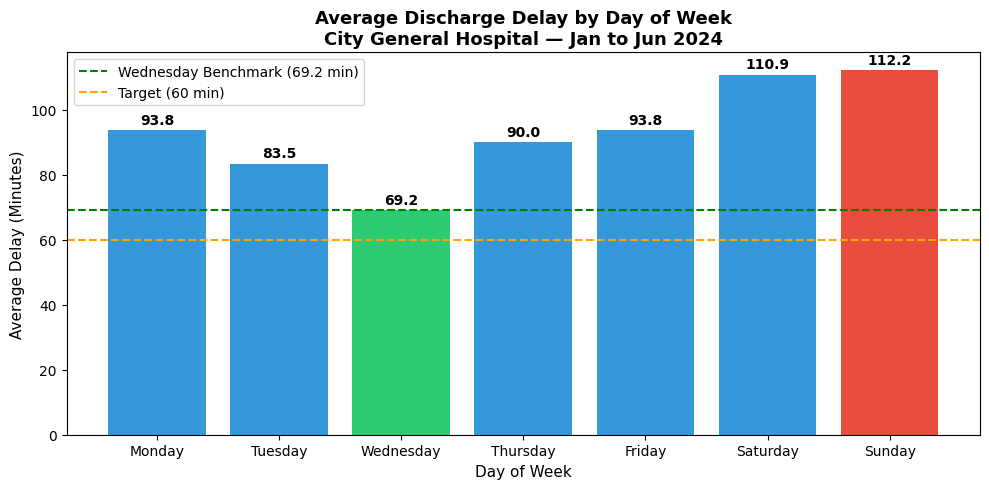

Chart saved as delay_by_day.png


In [ ]:
plt.figure(figsize=(10, 5))
colors = ['#2ecc71' if d == min(day_analysis)
          else '#e74c3c' if d == max(day_analysis)
          else '#3498db' for d in day_analysis]

bars = plt.bar(day_analysis.index, day_analysis.values, color=colors)

plt.axhline(y=day_analysis['Wednesday'], color='green',
            linestyle='--', linewidth=1.5, label='Wednesday Benchmark (69.2 min)')
plt.axhline(y=60, color='orange',
            linestyle='--', linewidth=1.5, label='Target (60 min)')

for bar, val in zip(bars, day_analysis.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.title('Average Discharge Delay by Day of Week\nCity General Hospital — Jan to Jun 2024',
          fontsize=13, fontweight='bold')
plt.xlabel('Day of Week', fontsize=11)
plt.ylabel('Average Delay (Minutes)', fontsize=11)
plt.legend()
plt.tight_layout()
plt.savefig('delay_by_day.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as delay_by_day.png")

2 Recommendations: "Deploy a dedicated weekend discharge support team covering pharmacy liaison, transport coordination, and documentation review on Saturdays and Sundays. Even a 2-person team focused specifically on discharge bottlenecks could recover an estimated 40+ minutes per patient across the weekend cohort." Recommendation number 2: "Where clinically appropriate, schedule elective discharges for Tuesday through Thursday when support capacity is highest. Reserve Friday discharges for urgent cases only, reducing the Friday afternoon bottleneck that carries into the weekend

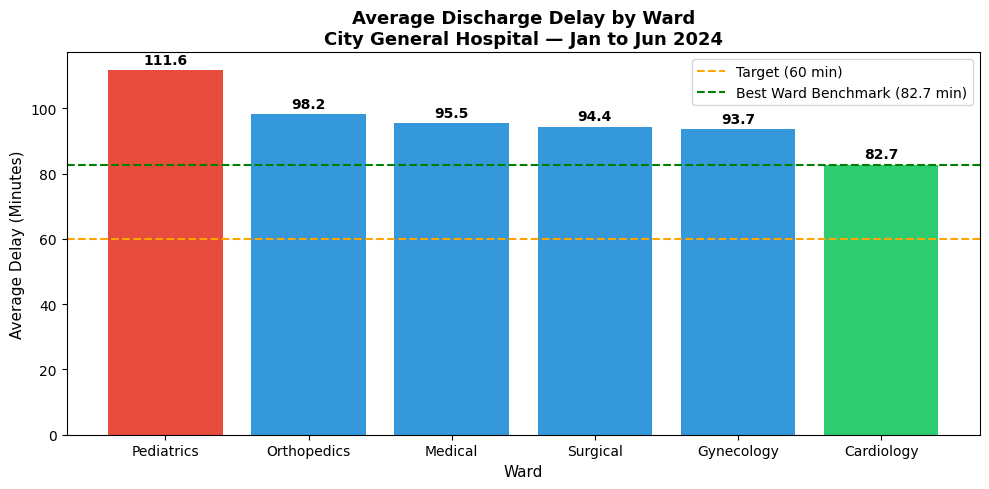

Chart saved as delay_by_ward.png


In [ ]:
plt.figure(figsize=(10, 5))

ward_avg = df.groupby('Ward')['Discharge_Delay_Minutes'].mean().sort_values(ascending=False).round(1)

colors = ['#e74c3c' if v == ward_avg.max()
          else '#2ecc71' if v == ward_avg.min()
          else '#3498db' for v in ward_avg]

bars = plt.bar(ward_avg.index, ward_avg.values, color=colors)

plt.axhline(y=60, color='orange', linestyle='--', linewidth=1.5, label='Target (60 min)')
plt.axhline(y=ward_avg.min(), color='green', linestyle='--', linewidth=1.5,
            label=f'Best Ward Benchmark ({ward_avg.min()} min)')

for bar, val in zip(bars, ward_avg.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.title('Average Discharge Delay by Ward\nCity General Hospital — Jan to Jun 2024',
          fontsize=13, fontweight='bold')
plt.xlabel('Ward', fontsize=11)
plt.ylabel('Average Delay (Minutes)', fontsize=11)
plt.legend()
plt.tight_layout()
plt.savefig('delay_by_ward.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as delay_by_ward.png")

Implement a mandatory family notification call 24 hours before anticipated discharge for all Pediatrics patients. The call should confirm pickup arrangements, transport needs, and any home care requirements. This directly addresses the 39% of Pediatrics delays caused by Family/Social factors."

Recommendation 2: Dedicated Pediatrics Transport Coordination

"Assign a discharge coordinator in Pediatrics responsible for booking patient transport at the time the discharge order is written — not after. Transport delays accounted for 9 cases in Pediatrics and are entirely preventable with proactive booking."

Recommendation 3: Pre-Discharge Clinical Review

"Introduce a daily 9am ward round specifically for anticipated same-day discharges. The physician confirms clinical readiness, pharmacy is notified immediately, and the family notification call is triggered simultaneously. This compresses the discharge timeline by eliminating sequential handoffs."

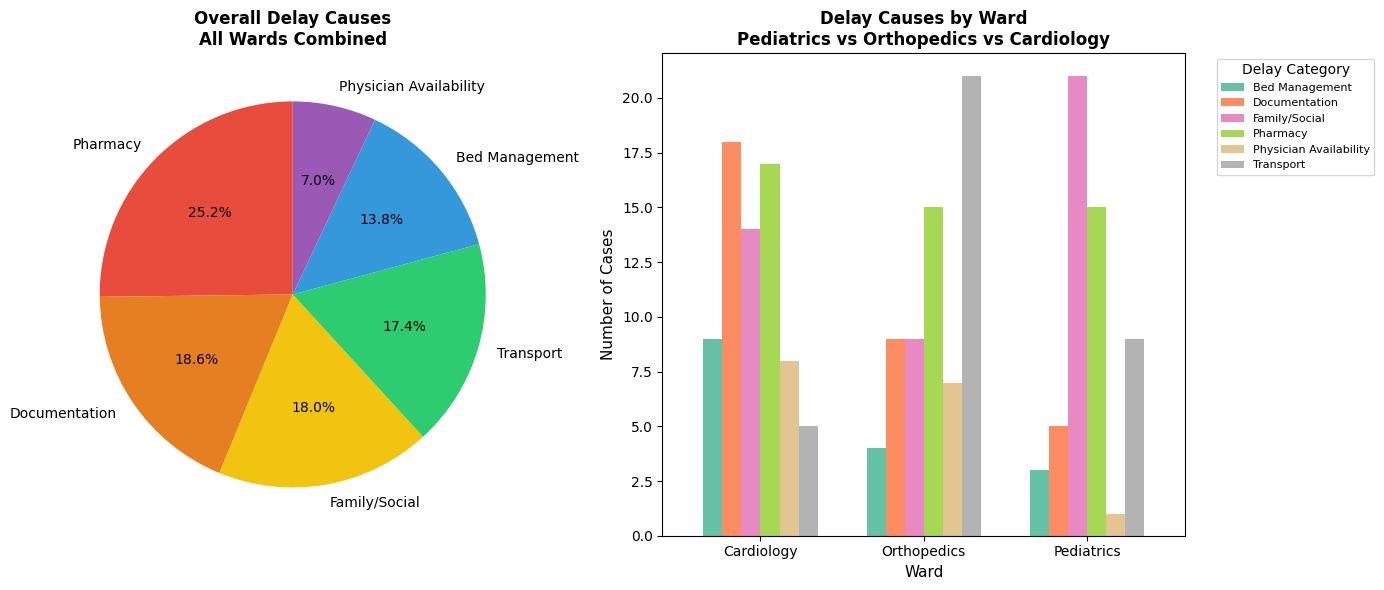

Chart saved as delay_categories.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Chart A: Overall delay categories ---
overall_cats = df['Delay_Category'].value_counts()
colors_pie = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db','#9b59b6']

axes[0].pie(overall_cats.values,
            labels=overall_cats.index,
            autopct='%1.1f%%',
            colors=colors_pie,
            startangle=90)
axes[0].set_title('Overall Delay Causes\nAll Wards Combined',
                  fontsize=12, fontweight='bold')

# --- Chart B: Top 3 wards delay category comparison ---
top_wards = ['Pediatrics', 'Orthopedics', 'Cardiology']
ward_cat_data = df[df['Ward'].isin(top_wards)].groupby(
    ['Ward','Delay_Category'])['Discharge_Delay_Minutes'].count().unstack(fill_value=0)

ward_cat_data.plot(kind='bar', ax=axes[1], colormap='Set2', width=0.7)
axes[1].set_title('Delay Causes by Ward\nPediatrics vs Orthopedics vs Cardiology',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Ward', fontsize=11)
axes[1].set_ylabel('Number of Cases', fontsize=11)
axes[1].legend(title='Delay Category', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('delay_categories.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as delay_categories.png")

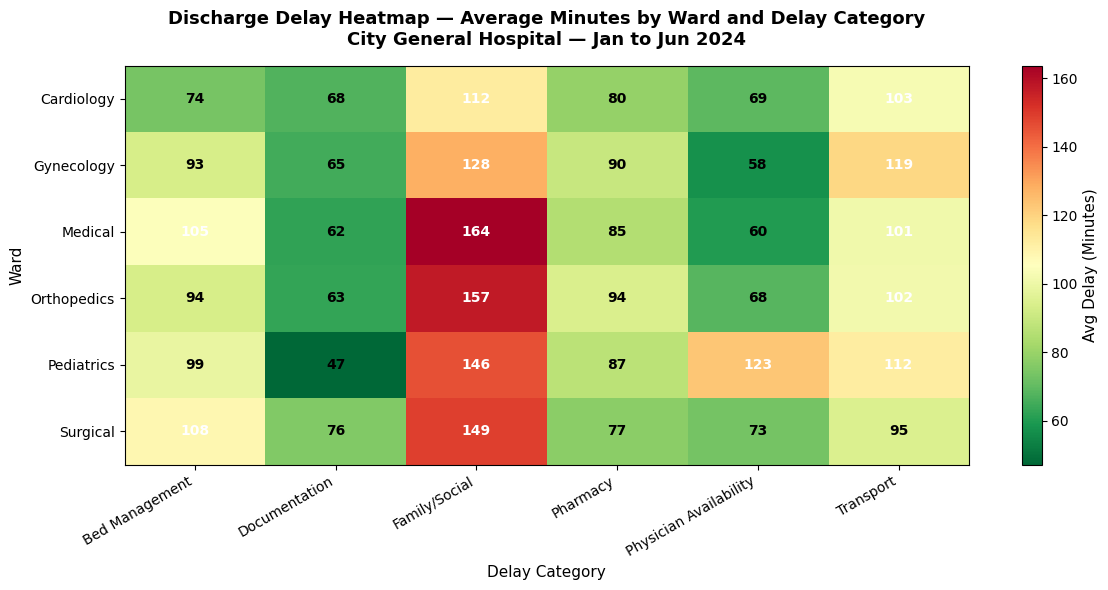

Chart saved as delay_heatmap.png


In [ ]:
import numpy as np

# Build heatmap data
heatmap_data = df.groupby(['Ward', 'Delay_Category'])['Discharge_Delay_Minutes'].mean().unstack(fill_value=0).round(1)

fig, ax = plt.subplots(figsize=(12, 6))

# Create heatmap manually
im = ax.imshow(heatmap_data.values, cmap='RdYlGn_r', aspect='auto')

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Avg Delay (Minutes)', fontsize=11)

# Add value labels inside each cell
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        val = heatmap_data.values[i, j]
        text_color = 'white' if val > 100 else 'black'
        ax.text(j, i, f'{val:.0f}', ha='center', va='center',
                fontsize=10, fontweight='bold', color=text_color)

# Labels
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_xticklabels(heatmap_data.columns, rotation=30, ha='right', fontsize=10)
ax.set_yticklabels(heatmap_data.index, fontsize=10)

ax.set_title('Discharge Delay Heatmap — Average Minutes by Ward and Delay Category\nCity General Hospital — Jan to Jun 2024',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Delay Category', fontsize=11)
ax.set_ylabel('Ward', fontsize=11)

plt.tight_layout()
plt.savefig('delay_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as delay_heatmap.png")

In [ ]:
!pip install reportlab

In [ ]:
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.lib.units import cm
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image, Table, TableStyle, HRFlowable
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.enums import TA_CENTER, TA_LEFT, TA_JUSTIFY
import os

doc = SimpleDocTemplate(
    "Discharge_Delay_Analysis_Report.pdf",
    pagesize=A4,
    rightMargin=2*cm, leftMargin=2*cm,
    topMargin=2*cm, bottomMargin=2*cm
)

styles = getSampleStyleSheet()

# Custom styles
title_style = ParagraphStyle('CustomTitle',
    parent=styles['Title'],
    fontSize=24, textColor=colors.HexColor('#1a3a5c'),
    spaceAfter=6, alignment=TA_CENTER, fontName='Helvetica-Bold')

subtitle_style = ParagraphStyle('Subtitle',
    parent=styles['Normal'],
    fontSize=13, textColor=colors.HexColor('#2c7bb6'),
    spaceAfter=4, alignment=TA_CENTER, fontName='Helvetica')

section_header_style = ParagraphStyle('SectionHeader',
    parent=styles['Heading1'],
    fontSize=14, textColor=colors.HexColor('#1a3a5c'),
    spaceBefore=16, spaceAfter=6,
    fontName='Helvetica-Bold',
    borderPad=4)

finding_style = ParagraphStyle('Finding',
    parent=styles['Normal'],
    fontSize=11, textColor=colors.HexColor('#2c3e50'),
    spaceAfter=6, leading=16,
    fontName='Helvetica', alignment=TA_JUSTIFY)

recommendation_style = ParagraphStyle('Recommendation',
    parent=styles['Normal'],
    fontSize=11, textColor=colors.HexColor('#1a5c2a'),
    spaceAfter=6, leading=16,
    fontName='Helvetica-Bold')

body_style = ParagraphStyle('Body',
    parent=styles['Normal'],
    fontSize=11, textColor=colors.HexColor('#2c3e50'),
    spaceAfter=6, leading=16,
    fontName='Helvetica', alignment=TA_JUSTIFY)

content = []

# ── COVER PAGE ──────────────────────────────────────────────
content.append(Spacer(1, 3*cm))
content.append(Paragraph("DISCHARGE DELAY ANALYSIS", title_style))
content.append(Paragraph("Bottleneck Identification & Operational Recommendations", subtitle_style))
content.append(Spacer(1, 0.5*cm))
content.append(HRFlowable(width="100%", thickness=2, color=colors.HexColor('#2c7bb6')))
content.append(Spacer(1, 0.3*cm))

meta_data = [
    ['Hospital:', 'City General Hospital (Synthetic Dataset)'],
    ['Analysis Period:', 'January 2024 — June 2024'],
    ['Total Records Analysed:', '500 Patient Discharge Records'],
    ['Prepared by:', 'Ishba Mujahid — Healthcare Operations Analyst'],
    ['Date:', 'June 2026'],
]
meta_table = Table(meta_data, colWidths=[5*cm, 11*cm])
meta_table.setStyle(TableStyle([
    ('FONTNAME', (0,0), (0,-1), 'Helvetica-Bold'),
    ('FONTNAME', (1,0), (1,-1), 'Helvetica'),
    ('FONTSIZE', (0,0), (-1,-1), 11),
    ('TEXTCOLOR', (0,0), (0,-1), colors.HexColor('#1a3a5c')),
    ('TEXTCOLOR', (1,0), (1,-1), colors.HexColor('#2c3e50')),
    ('BOTTOMPADDING', (0,0), (-1,-1), 8),
    ('TOPPADDING', (0,0), (-1,-1), 8),
]))
content.append(meta_table)
content.append(Spacer(1, 0.5*cm))
content.append(HRFlowable(width="100%", thickness=1, color=colors.HexColor('#cccccc')))

# ── EXECUTIVE SUMMARY ───────────────────────────────────────
content.append(Spacer(1, 0.8*cm))
content.append(Paragraph("Executive Summary", section_header_style))
content.append(HRFlowable(width="100%", thickness=1, color=colors.HexColor('#2c7bb6')))
content.append(Spacer(1, 0.3*cm))

exec_summary = """This report presents a data-driven analysis of discharge delays across six wards at City General
Hospital over a six-month period from January to June 2024. Analysis of 500 patient discharge records
identified a hospital-wide average discharge delay of 95.3 minutes — significantly above the 60-minute
operational target. The delay pattern is systemic rather than exception-driven, indicating a structural
workflow problem requiring targeted operational interventions. Three high-priority recommendations are
presented, with projected impact on bed availability, patient throughput, and operational efficiency."""
content.append(Paragraph(exec_summary, body_style))

# ── KEY METRICS ─────────────────────────────────────────────
content.append(Spacer(1, 0.5*cm))
content.append(Paragraph("Key Metrics at a Glance", section_header_style))
content.append(HRFlowable(width="100%", thickness=1, color=colors.HexColor('#2c7bb6')))
content.append(Spacer(1, 0.3*cm))

metrics_data = [
    ['Metric', 'Value', 'Benchmark', 'Status'],
    ['Average Discharge Delay', '95.3 minutes', '60 minutes', 'ABOVE TARGET'],
    ['Median Discharge Delay', '91.0 minutes', '60 minutes', 'ABOVE TARGET'],
    ['Longest Single Delay', '240 minutes', '—', 'CRITICAL'],
    ['Best Performing Ward', 'Cardiology (82.7 min)', '—', 'MONITOR'],
    ['Worst Performing Ward', 'Pediatrics (111.6 min)', '—', 'PRIORITY'],
    ['Worst Performing Day', 'Sunday (112.2 min)', '—', 'PRIORITY'],
    ['Best Performing Day', 'Wednesday (69.2 min)', '—', 'BENCHMARK'],
]
metrics_table = Table(metrics_data, colWidths=[5.5*cm, 4.5*cm, 3.5*cm, 3*cm])
metrics_table.setStyle(TableStyle([
    ('BACKGROUND', (0,0), (-1,0), colors.HexColor('#1a3a5c')),
    ('TEXTCOLOR', (0,0), (-1,0), colors.white),
    ('FONTNAME', (0,0), (-1,0), 'Helvetica-Bold'),
    ('FONTNAME', (0,1), (-1,-1), 'Helvetica'),
    ('FONTSIZE', (0,0), (-1,-1), 10),
    ('ROWBACKGROUNDS', (0,1), (-1,-1),
     [colors.HexColor('#f0f4f8'), colors.white]),
    ('GRID', (0,0), (-1,-1), 0.5, colors.HexColor('#cccccc')),
    ('ALIGN', (0,0), (-1,-1), 'CENTER'),
    ('VALIGN', (0,0), (-1,-1), 'MIDDLE'),
    ('BOTTOMPADDING', (0,0), (-1,-1), 8),
    ('TOPPADDING', (0,0), (-1,-1), 8),
    ('TEXTCOLOR', (3,1), (3,-1), colors.HexColor('#c0392b')),
    ('FONTNAME', (3,1), (3,-1), 'Helvetica-Bold'),
]))
content.append(metrics_table)

# ── FINDINGS ────────────────────────────────────────────────
content.append(Spacer(1, 0.8*cm))
content.append(Paragraph("Analytical Findings", section_header_style))
content.append(HRFlowable(width="100%", thickness=1, color=colors.HexColor('#2c7bb6')))
content.append(Spacer(1, 0.3*cm))

findings = [
    ("Finding 1 — Systemic Delay Pattern",
     "The hospital-wide average discharge delay of 95.3 minutes significantly exceeds the 60-minute operational target. The proximity of the mean (95.3 min) and median (91.0 min) confirms that delays are distributed consistently across the patient population rather than driven by isolated extreme cases. This indicates a structural workflow problem requiring systemic intervention rather than exception management."),
    ("Finding 2 — Significant Ward Performance Inequality",
     "A 29-minute performance gap exists between the best performing ward (Cardiology, 82.7 min) and the worst performing ward (Pediatrics, 111.6 min). Pediatrics delays are 35% higher than the internal benchmark set by Cardiology. This gap represents preventable bed occupancy and provides a clear internal benchmark for improvement."),
    ("Finding 3 — Pediatrics Root Cause Identified",
     "39% of all Pediatrics discharge delays are attributable to Family and Social factors — the single most dominant delay cause in any ward. This concentration in one category indicates a targeted, solvable problem. In contrast, Cardiology delays are distributed evenly across categories, explaining its stronger overall performance."),
    ("Finding 4 — Critical Weekend Performance Deterioration",
     "Weekend discharge delays are 63% higher than the Wednesday benchmark (112.2 min vs 69.2 min). Friday already shows elevation at 93.8 minutes, suggesting an end-of-week discharge surge that overwhelms weekend support capacity. This pattern is consistent with reduced pharmacy, transport, and administrative staffing on weekends."),
]

for title, text in findings:
    content.append(Paragraph(f"<b>{title}</b>", recommendation_style))
    content.append(Paragraph(text, finding_style))
    content.append(Spacer(1, 0.3*cm))

# ── CHARTS ──────────────────────────────────────────────────
content.append(Spacer(1, 0.3*cm))
content.append(Paragraph("Visual Analysis", section_header_style))
content.append(HRFlowable(width="100%", thickness=1, color=colors.HexColor('#2c7bb6')))
content.append(Spacer(1, 0.3*cm))

chart_files = [
    ('delay_by_day.png', 'Figure 1: Average Discharge Delay by Day of Week'),
    ('delay_by_ward.png', 'Figure 2: Average Discharge Delay by Ward'),
    ('delay_categories.png', 'Figure 3: Delay Cause Analysis — Overall and by Ward'),
    ('delay_heatmap.png', 'Figure 4: Discharge Delay Heatmap — Ward vs Delay Category'),
]

caption_style = ParagraphStyle('Caption',
    parent=styles['Normal'],
    fontSize=9, textColor=colors.HexColor('#666666'),
    spaceAfter=12, alignment=TA_CENTER,
    fontName='Helvetica-Oblique')

for filename, caption in chart_files:
    if os.path.exists(filename):
        img = Image(filename, width=16*cm, height=8*cm)
        content.append(img)
        content.append(Paragraph(caption, caption_style))
        content.append(Spacer(1, 0.3*cm))

# ── RECOMMENDATIONS ─────────────────────────────────────────
content.append(Paragraph("Recommendations", section_header_style))
content.append(HRFlowable(width="100%", thickness=1, color=colors.HexColor('#2c7bb6')))
content.append(Spacer(1, 0.3*cm))

recommendations = [
    ("Recommendation 1 — 24-Hour Family Notification Protocol (Pediatrics)",
     "Implement a mandatory family notification call 24 hours before anticipated discharge for all Pediatrics patients. The call should confirm pickup arrangements, transport needs, and home care requirements. This directly targets the 39% of Pediatrics delays driven by Family and Social factors and is implementable immediately without additional capital expenditure."),
    ("Recommendation 2 — Weekend Discharge Support Team",
     "Deploy a dedicated weekend discharge coordinator covering pharmacy liaison, transport coordination, and documentation review on Saturdays and Sundays. Weekend delays of 112 minutes represent a 63% premium over the Wednesday benchmark. A two-person weekend discharge team is projected to recover 30-40 minutes per patient across the weekend cohort."),
    ("Recommendation 3 — Discharge Smoothing and Pre-Discharge Clinical Review",
     "Where clinically appropriate, schedule elective discharges toward Tuesday through Thursday when support capacity is highest. Introduce a daily 9am ward round for anticipated same-day discharges to trigger simultaneous pharmacy notification, transport booking, and family communication — compressing the discharge timeline by eliminating sequential handoffs."),
]

for title, text in recommendations:
    content.append(Paragraph(f"<b>{title}</b>", recommendation_style))
    content.append(Paragraph(text, finding_style))
    content.append(Spacer(1, 0.3*cm))

# ── CONCLUSION ──────────────────────────────────────────────
content.append(Spacer(1, 0.3*cm))
content.append(Paragraph("Conclusion", section_header_style))
content.append(HRFlowable(width="100%", thickness=1, color=colors.HexColor('#2c7bb6')))
content.append(Spacer(1, 0.3*cm))

conclusion = """This analysis demonstrates that discharge delays at City General Hospital are systemic, measurable,
and addressable through targeted operational interventions. The data identifies clear priority areas —
Pediatrics ward and weekend operations — where focused improvements would generate the highest impact
on bed availability and patient throughput. Implementation of the three recommendations outlined in this
report is projected to reduce average discharge delay by 25-35 minutes per patient, recovering significant
bed capacity and improving patient experience across all wards. A follow-up measurement cycle of 90 days
post-implementation is recommended to validate impact and identify further optimisation opportunities."""
content.append(Paragraph(conclusion, body_style))

content.append(Spacer(1, 1*cm))
content.append(HRFlowable(width="100%", thickness=1, color=colors.HexColor('#cccccc')))
content.append(Spacer(1, 0.3*cm))
content.append(Paragraph("Prepared by Ishba Mujahid — Healthcare Operations Portfolio Project | June 2026",
                         ParagraphStyle('Footer', parent=styles['Normal'],
                         fontSize=9, textColor=colors.HexColor('#999999'),
                         alignment=TA_CENTER)))

# BUILD PDF
doc.build(content)
print("Report generated: Discharge_Delay_Analysis_Report.pdf")

Report generated: Discharge_Delay_Analysis_Report.pdf


In [ ]:
pip install reportlab